Loading FinBERT model (downloads ~500MB on first run)...
Using device: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅  FinBERT loaded successfully
Building sentiment dataset (this will take several hours for 300 stocks)
Tip: Run for a subset first to test, then run the full batch overnight.


Fetching sentiment:   0%|          | 0/10 [00:00<?, ?it/s]Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "C:\Users\athar\anaconda3\envs\stock_ai\Lib\site-packages\httpx\_transports\default.py", line 101, in map_httpcore_exceptions
    yield
  File "C:\Users\athar\anaconda3\envs\stock_ai\Lib\site-packages\httpx\_transports\default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\athar\anaconda3\envs\stock_ai\Lib\site-packages\httpcore\_sync\connection_pool.py", line 256, in handle_request
    raise exc from None
  File "C:\Users\athar\anaconda3\envs\stock_ai\Lib\site-packages\httpcore\_sync\connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\athar\anaconda3\envs\stock_ai\Lib\site-packages\httpcore\_sync\connection.py", line 101, in handle_request
    raise exc
  File "

✅  Saved → data/sentiment/master_sentiment.csv
Sentiment rows: 480
   Sent_Positive  Sent_Negative  Sent_Neutral  Sent_Score  News_Count  \
0            0.0            0.0           1.0         0.0           0   
1            0.0            0.0           1.0         0.0           0   
2            0.0            0.0           1.0         0.0           0   
3            0.0            0.0           1.0         0.0           0   
4            0.0            0.0           1.0         0.0           0   

        Ticker       Date  
0  ADANIENT.NS 2021-01-31  
1  ADANIENT.NS 2021-02-28  
2  ADANIENT.NS 2021-03-31  
3  ADANIENT.NS 2021-04-30  
4  ADANIENT.NS 2021-05-31  


Merging: 100%|██████████| 134/134 [00:02<00:00, 54.39it/s]



✅  Fusion dataset saved → data/fusion/master_fusion.csv  (130,883 rows)

=== SENTIMENT STATISTICS ===
       Sent_Positive  Sent_Negative  Sent_Neutral  Sent_Score  News_Count
count    130883.0000    130883.0000   130883.0000    130883.0    130883.0
mean          0.0001         0.0001        0.9999         0.0         0.0
std           0.0041         0.0041        0.0082         0.0         0.0
min           0.0000         0.0000        0.3400         0.0         0.0
25%           0.0000         0.0000        1.0000         0.0         0.0
50%           0.0000         0.0000        1.0000         0.0         0.0
75%           0.0000         0.0000        1.0000         0.0         0.0
max           0.3300         0.3300        1.0000         0.0         0.0

Sentiment by Cap Type:
          Sent_Score  News_Count
Cap_Type                        
large            0.0         0.0
mid              0.0         0.0
small            0.0         0.0


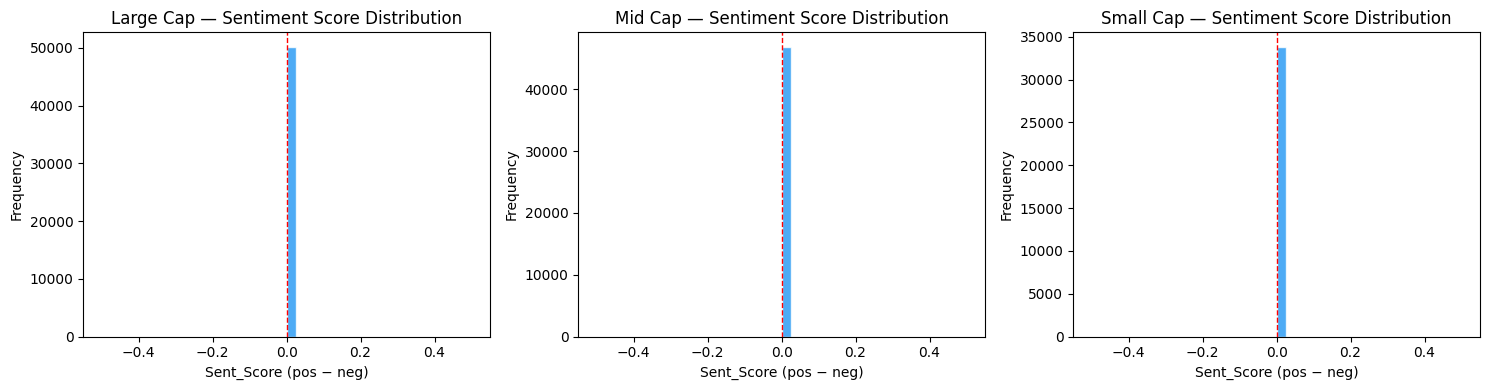


  TRAINING FUSION MODEL (Technical + Sentiment)
Fusion train: 104,619 | test: 26,264

  Fusion Model Results:
  Accuracy  : 0.6178
  F1 Score  : 0.1034
  ROC AUC   : 0.5202

  Classification Report:
              precision    recall  f1-score   support

     Bearish       0.63      0.96      0.76     16359
     Bullish       0.45      0.06      0.10      9905

    accuracy                           0.62     26264
   macro avg       0.54      0.51      0.43     26264
weighted avg       0.56      0.62      0.51     26264

💾  Saved → models/fusion_xgb.pkl

  PHASE 4 COMPLETE
  Saved:
    data/sentiment/master_sentiment.csv
    data/fusion/master_fusion.csv
    models/fusion_xgb.pkl
    plots/sentiment_distribution.png

➡  Next: Run phase5_dashboard.py


In [1]:
# ============================================================
#  PHASE 4 — FINBERT SENTIMENT + FUSION MODEL
#  Stock Price Prediction & Analysis System
# ============================================================
# Prerequisites: Phase 1-3 complete
# Input : data/processed/master_features.csv
#         NewsAPI key (free at newsapi.org)
# Output: data/sentiment/master_sentiment.csv
#         data/fusion/master_fusion.csv
#         models/fusion_xgb.pkl
# ============================================================

# ── CELL 1: Install & Imports ────────────────────────────────
# !pip install transformers torch newsapi-python requests joblib tqdm

import os, time, json, warnings, joblib, requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm import tqdm
from newsapi import NewsApiClient
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, f1_score)
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
os.makedirs("data/sentiment", exist_ok=True)
os.makedirs("data/fusion",    exist_ok=True)
os.makedirs("models",         exist_ok=True)

# ── CELL 2: Configuration ────────────────────────────────────
NEWS_API_KEY  = "YOUR_NEWS_API_KEY_HERE"  # ← Replace with key from newsapi.org (free)
SENTIMENT_CSV = "data/sentiment/master_sentiment.csv"
FUSION_CSV    = "data/fusion/master_fusion.csv"

FEATURE_COLS  = [
    "EMA50","EMA200","MACD","MACD_Signal","EMA_RATIO",
    "RSI14","Stoch_K","Stoch_D","ROC10","MOM10",
    "ATR14","BB_Upper","BB_Lower","BB_Width","RollingStd20",
    "OBV","VWAP","Vol_Ratio20","Cap_Encoded"
]
SENTIMENT_COLS = ["Sent_Positive","Sent_Negative","Sent_Neutral","Sent_Score","News_Count"]
FUSION_COLS    = FEATURE_COLS + SENTIMENT_COLS
TARGET         = "Target"

# ── CELL 3: Load FinBERT Model ───────────────────────────────
print("Loading FinBERT model (downloads ~500MB on first run)...")
FINBERT_MODEL = "ProsusAI/finbert"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

tokenizer  = AutoTokenizer.from_pretrained(FINBERT_MODEL)
finbert    = AutoModelForSequenceClassification.from_pretrained(FINBERT_MODEL)
finbert    = finbert.to(device)
finbert.eval()
print("✅  FinBERT loaded successfully")

# ── CELL 4: Sentiment Inference Function ─────────────────────
def get_sentiment(texts: list[str], batch_size: int = 8) -> dict:
    """
    Run FinBERT on a list of headlines.
    Returns: {positive, negative, neutral, score, count}
    score = positive - negative (range: -1 to +1)
    """
    if not texts:
        return {"Sent_Positive": 0.0, "Sent_Negative": 0.0,
                "Sent_Neutral": 1.0,  "Sent_Score": 0.0, "News_Count": 0}

    all_pos, all_neg, all_neu = [], [], []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc   = tokenizer(batch, padding=True, truncation=True,
                           max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = finbert(**enc).logits
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        # FinBERT label order: [positive, negative, neutral]
        all_pos.extend(probs[:, 0].tolist())
        all_neg.extend(probs[:, 1].tolist())
        all_neu.extend(probs[:, 2].tolist())

    return {
        "Sent_Positive": round(np.mean(all_pos), 4),
        "Sent_Negative": round(np.mean(all_neg), 4),
        "Sent_Neutral" : round(np.mean(all_neu), 4),
        "Sent_Score"   : round(np.mean(all_pos) - np.mean(all_neg), 4),
        "News_Count"   : len(texts)
    }

# ── CELL 5: NewsAPI Fetcher ──────────────────────────────────
newsapi = NewsApiClient(api_key=NEWS_API_KEY)

def fetch_headlines(company_name: str, date: str, window_days: int = 1) -> list[str]:
    """
    Fetch news headlines for a company around a given date.
    date format: 'YYYY-MM-DD'
    """
    try:
        from_dt = (datetime.strptime(date, "%Y-%m-%d") - timedelta(days=window_days)).strftime("%Y-%m-%d")
        to_dt   = date

        resp = newsapi.get_everything(
            q          = f'"{company_name}" stock',
            from_param = from_dt,
            to         = to_dt,
            language   = "en",
            sort_by    = "relevancy",
            page_size  = 10,
        )
        articles  = resp.get("articles", [])
        headlines = [a["title"] for a in articles if a.get("title")]
        return headlines
    except Exception:
        return []

# ── CELL 6: Map Tickers to Company Names ─────────────────────
# NSE ticker → company name for better NewsAPI queries
TICKER_NAME_MAP = {
    "RELIANCE.NS":"Reliance Industries","TCS.NS":"TCS Tata Consultancy",
    "HDFCBANK.NS":"HDFC Bank","INFY.NS":"Infosys","ICICIBANK.NS":"ICICI Bank",
    "HINDUNILVR.NS":"Hindustan Unilever","SBIN.NS":"State Bank India",
    "BHARTIARTL.NS":"Bharti Airtel","ITC.NS":"ITC Limited",
    "KOTAKBANK.NS":"Kotak Mahindra Bank","LT.NS":"Larsen Toubro",
    "AXISBANK.NS":"Axis Bank","ASIANPAINT.NS":"Asian Paints",
    "MARUTI.NS":"Maruti Suzuki","SUNPHARMA.NS":"Sun Pharmaceutical",
    "TITAN.NS":"Titan Company","BAJFINANCE.NS":"Bajaj Finance",
    "WIPRO.NS":"Wipro","NESTLEIND.NS":"Nestle India",
    "ZOMATO.NS":"Zomato","NYKAA.NS":"Nykaa FSN","IRCTC.NS":"IRCTC",
    "DMART.NS":"D-Mart Avenue Supermarts","PERSISTENT.NS":"Persistent Systems",
    "MPHASIS.NS":"Mphasis","LTIM.NS":"LTIMindtree","COFORGE.NS":"Coforge",
    "RAILTEL.NS":"RailTel Corporation","IRFC.NS":"IRFC India",
    "RVNL.NS":"Rail Vikas Nigam","GRSE.NS":"Garden Reach Shipbuilders",
}

def ticker_to_name(ticker: str) -> str:
    """Convert NSE ticker to company name for news search."""
    if ticker in TICKER_NAME_MAP:
        return TICKER_NAME_MAP[ticker]
    # Fallback: strip .NS and clean up
    return ticker.replace(".NS","").replace("-"," ").title()

# ── CELL 7: Batch Sentiment Pipeline ────────────────────────
# Strategy: sample 1 date per week per ticker to stay within API limits
# NewsAPI free tier: 100 requests/day

def build_sentiment_dataset(master: pd.DataFrame,
                             sample_freq: str = "W",
                             delay: float = 0.5) -> pd.DataFrame:
    """
    For each ticker × sampled date, fetch news and run FinBERT.
    Then forward-fill sentiment to daily frequency.
    """
    results = []
    tickers = master["Ticker"].unique()

    for ticker in tqdm(tickers, desc="Fetching sentiment"):
        company_name = ticker_to_name(ticker)
        df_t = master[master["Ticker"] == ticker].sort_values("Date")

        # Sample dates (weekly to limit API calls)
        sample_dates = df_t.set_index("Date").resample(sample_freq).first().index
        sample_dates = [d.strftime("%Y-%m-%d") for d in sample_dates]

        for date_str in sample_dates:
            headlines = fetch_headlines(company_name, date_str)
            sent = get_sentiment(headlines)
            sent["Ticker"] = ticker
            sent["Date"]   = date_str
            results.append(sent)
            time.sleep(delay)

    sent_df = pd.DataFrame(results)
    sent_df["Date"] = pd.to_datetime(sent_df["Date"])
    return sent_df

# ── CELL 8: Load or Build Sentiment ──────────────────────────
master = pd.read_csv("data/processed/master_features.csv", parse_dates=["Date"])

if os.path.exists(SENTIMENT_CSV):
    print(f"Loading cached sentiment → {SENTIMENT_CSV}")
    sentiment_df = pd.read_csv(SENTIMENT_CSV, parse_dates=["Date"])
else:
    print("Building sentiment dataset (this will take several hours for 300 stocks)")
    print("Tip: Run for a subset first to test, then run the full batch overnight.")

    # ── OPTION A: Run for all tickers ─────────────────────
    # sentiment_df = build_sentiment_dataset(master)

    # ── OPTION B: Run for a small test subset ─────────────
    test_tickers = master["Ticker"].unique()[:10]
    test_master  = master[master["Ticker"].isin(test_tickers)]
    sentiment_df = build_sentiment_dataset(test_master, sample_freq="M")

    sentiment_df.to_csv(SENTIMENT_CSV, index=False)
    print(f"✅  Saved → {SENTIMENT_CSV}")

print(f"Sentiment rows: {len(sentiment_df):,}")
print(sentiment_df.head())

# ── CELL 9: Forward-Fill Sentiment to Daily ──────────────────
def ffill_sentiment_to_daily(master: pd.DataFrame,
                              sentiment: pd.DataFrame) -> pd.DataFrame:
    """
    Merge weekly/monthly sentiment onto daily stock data.
    Forward-fill sentiment scores between sample dates.
    """
    merged_list = []
    for ticker in tqdm(master["Ticker"].unique(), desc="Merging"):
        df_m = master[master["Ticker"] == ticker].copy().sort_values("Date")
        df_s = sentiment[sentiment["Ticker"] == ticker].copy().sort_values("Date")

        if df_s.empty:
            # No sentiment data — fill with neutral
            for col in SENTIMENT_COLS:
                df_m[col] = 0.0
            df_m["Sent_Neutral"] = 1.0
            df_m["News_Count"]   = 0
        else:
            # Merge on nearest date, then forward-fill
            df_m = pd.merge_asof(df_m, df_s[["Date"] + SENTIMENT_COLS],
                                  on="Date", direction="backward")
            # Fill any remaining NaN with neutral
            df_m[SENTIMENT_COLS] = df_m[SENTIMENT_COLS].fillna({
                "Sent_Positive": 0.33, "Sent_Negative": 0.33,
                "Sent_Neutral": 0.34,  "Sent_Score": 0.0, "News_Count": 0
            })

        merged_list.append(df_m)

    return pd.concat(merged_list, ignore_index=True)

fusion_df = ffill_sentiment_to_daily(master, sentiment_df)
fusion_df.to_csv(FUSION_CSV, index=False)
print(f"\n✅  Fusion dataset saved → {FUSION_CSV}  ({len(fusion_df):,} rows)")

# ── CELL 10: Sentiment Statistics ───────────────────────────
print("\n=== SENTIMENT STATISTICS ===")
print(fusion_df[SENTIMENT_COLS].describe().round(4))
print(f"\nSentiment by Cap Type:")
print(fusion_df.groupby("Cap_Type")[["Sent_Score","News_Count"]].mean().round(4))

# Plot sentiment distribution
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cap in zip(axes, ["large","mid","small"]):
    sub = fusion_df[fusion_df["Cap_Type"] == cap]["Sent_Score"]
    ax.hist(sub.dropna(), bins=40, color="#2196F3", edgecolor="white", alpha=0.8)
    ax.set_title(f"{cap.title()} Cap — Sentiment Score Distribution")
    ax.set_xlabel("Sent_Score (pos − neg)")
    ax.set_ylabel("Frequency")
    ax.axvline(0, color="red", linestyle="--", lw=1)
plt.tight_layout()
plt.savefig("plots/sentiment_distribution.png", dpi=150)
plt.show()

# ── CELL 11: Fusion Model Training ──────────────────────────
print("\n" + "="*55)
print("  TRAINING FUSION MODEL (Technical + Sentiment)")
print("="*55)

# Drop rows without both technical and sentiment features
fusion_clean = fusion_df.dropna(subset=FUSION_COLS + [TARGET])
split_date   = fusion_clean["Date"].quantile(0.8)
train_f      = fusion_clean[fusion_clean["Date"] <  split_date]
test_f       = fusion_clean[fusion_clean["Date"] >= split_date]

print(f"Fusion train: {len(train_f):,} | test: {len(test_f):,}")

X_train = train_f[FUSION_COLS].values
y_train = train_f[TARGET].values
X_test  = test_f[FUSION_COLS].values
y_test  = test_f[TARGET].values

# Train fusion XGBoost
fusion_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("xgb", XGBClassifier(
        n_estimators     = 500,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.7,
        use_label_encoder= False,
        eval_metric      = "logloss",
        random_state     = 42,
        tree_method      = "hist",
    ))
])
fusion_pipe.fit(X_train, y_train)

# Evaluate
y_pred  = fusion_pipe.predict(X_test)
y_prob  = fusion_pipe.predict_proba(X_test)[:, 1]

print(f"\n  Fusion Model Results:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Bearish","Bullish"]))

joblib.dump(fusion_pipe, "models/fusion_xgb.pkl")
print("💾  Saved → models/fusion_xgb.pkl")

# ── CELL 12: Prediction Interface ───────────────────────────
def predict_stock(ticker: str, date: str,
                  technical_row: dict,
                  news_headlines: list[str] = None) -> dict:
    """
    Live prediction for a single stock on a given date.
    Returns: prediction label, probability, sentiment breakdown.

    Args:
        ticker          : NSE ticker e.g. 'RELIANCE.NS'
        date            : 'YYYY-MM-DD'
        technical_row   : dict with all 19 technical feature values
        news_headlines  : list of recent news headlines (optional)
    """
    model = joblib.load("models/fusion_xgb.pkl")

    # Sentiment
    if news_headlines:
        sent = get_sentiment(news_headlines)
    else:
        headlines = fetch_headlines(ticker_to_name(ticker), date)
        sent = get_sentiment(headlines)

    # Build feature vector
    row = {**technical_row, **sent}
    X   = pd.DataFrame([row])[FUSION_COLS].values

    prob  = model.predict_proba(X)[0, 1]
    label = "Bullish 📈" if prob > 0.5 else "Bearish 📉"

    return {
        "Ticker"     : ticker,
        "Date"       : date,
        "Prediction" : label,
        "Confidence" : f"{prob*100:.1f}%",
        "Sentiment"  : {
            "Score"    : sent["Sent_Score"],
            "Positive" : sent["Sent_Positive"],
            "Negative" : sent["Sent_Negative"],
            "Articles" : sent["News_Count"]
        }
    }

# Example usage:
# result = predict_stock("RELIANCE.NS", "2024-12-01", technical_row={...})
# print(result)

print("\n" + "="*55)
print("  PHASE 4 COMPLETE")
print("="*55)
print("  Saved:")
print("    data/sentiment/master_sentiment.csv")
print("    data/fusion/master_fusion.csv")
print("    models/fusion_xgb.pkl")
print("    plots/sentiment_distribution.png")
print("\n➡  Next: Run phase5_dashboard.py")